# Calibração dos Modelos
Avalia se as probabilidades previstas correspondem às frequências reais de óbito.
Um modelo perfeitamente calibrado que prevê p=0.70 tem ~70% de óbitos naquele grupo.
**Nenhum modelo novo é gerado** — análise apenas sobre os `_predicoes.parquet` existentes.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

OUTPUT_MET = '../../output/metricas'
OUTPUT_PLT = '../../output/plots'
os.makedirs(OUTPUT_PLT, exist_ok=True)

LABEL_MAP = {
    'logistic_regression_baseline':          'LR',
    'logistic_regression_baseline_tuned':    'LR (tuned)',
    'logistic_regression_smote_1_1':         'LR + SMOTE 1:1',
    'logistic_regression_smote_1_5':         'LR + SMOTE 1:5',
    'logistic_regression_smote_1_10':        'LR + SMOTE 1:10',
    'mlp_baseline':                          'MLP',
    'mlp_baseline_tuned':                    'MLP (tuned)',
    'lightgbm_baseline':                     'LightGBM',
    'lightgbm_baseline_tuned':               'LightGBM (tuned)',
    'xgboost_baseline':                      'XGBoost',
    'xgboost_baseline_tuned':                'XGBoost (tuned)',
    'random_forest_baseline':                'Random Forest',
    'random_forest_baseline_tuned':          'Random Forest (tuned)',
    'naive_bayes_baseline':                  'Naive Bayes',
    'ensemble_lr_lr_tuned_mlp_lgbm_tuned':   'Ensemble (LR+MLP+LGBM)',
}

# Categorias de risco do sistema de scoring
BINS  = [0.0, 0.10, 0.30, 0.60, 1.01]
CATS  = ['BAIXO RISCO', 'MODERADO', 'ALTO RISCO', 'CRÍTICO']
N_BINS_CAL = 10  # bins para calibration_curve

## 1. Carregamento das predições

In [2]:
predicoes = {}
for f in sorted(os.listdir(OUTPUT_MET)):
    if not f.endswith('_predicoes.parquet'):
        continue
    base  = f.replace('_predicoes.parquet', '')
    df    = pd.read_parquet(os.path.join(OUTPUT_MET, f))
    predicoes[base] = {
        'label':   LABEL_MAP.get(base, base),
        'y_true':  df['y_true'].values,
        'y_proba': df['y_proba'].values,
    }

print(f'{len(predicoes)} modelos carregados')

11 modelos carregados


## 2. Reliability diagrams — todos os modelos
Cada ponto representa um bin de probabilidade. A diagonal perfeita indica calibração ideal.

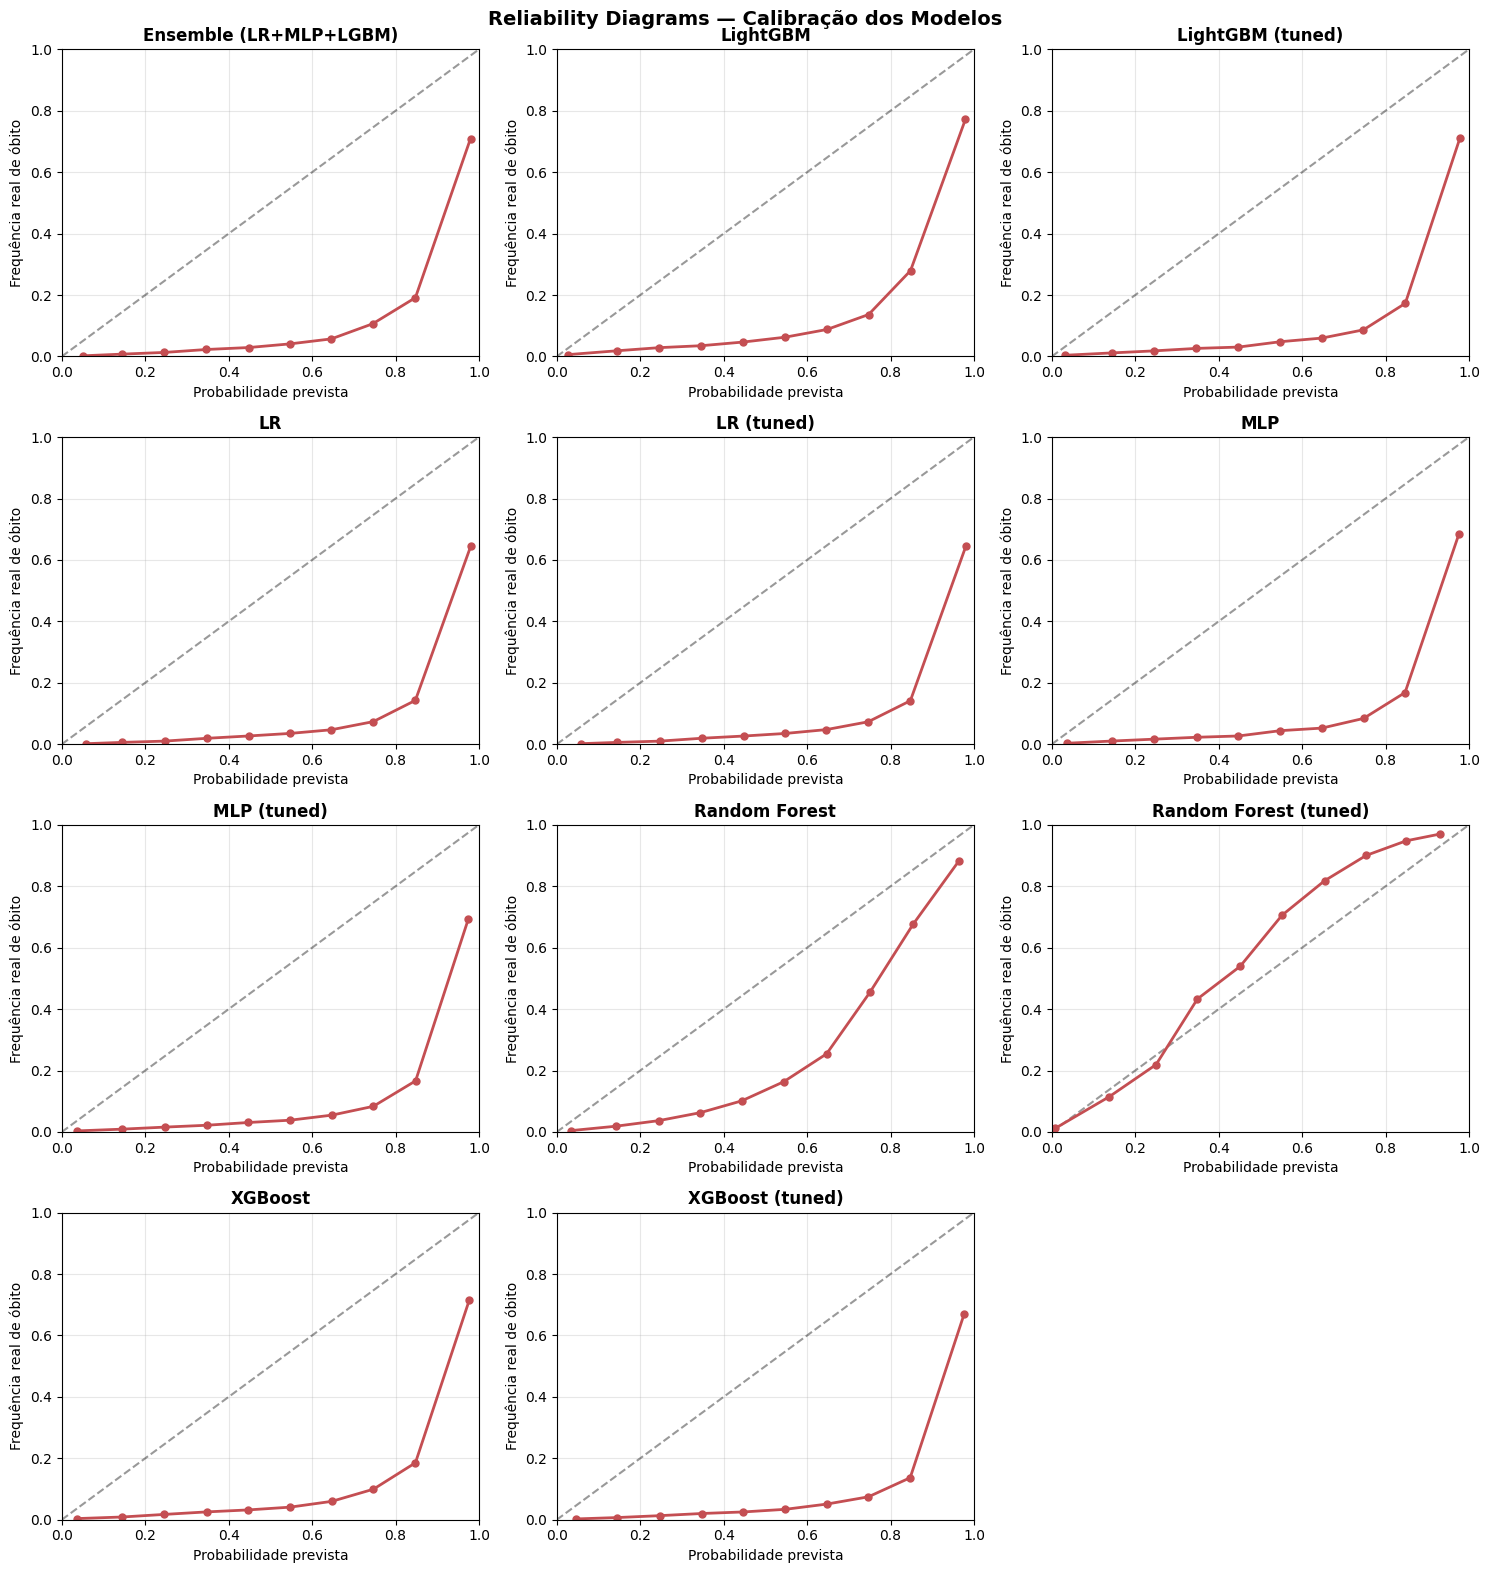

In [3]:
n     = len(predicoes)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, (base, info) in enumerate(predicoes.items()):
    ax = axes[i]
    prob_true, prob_pred = calibration_curve(
        info['y_true'], info['y_proba'], n_bins=N_BINS_CAL, strategy='uniform'
    )
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Calibração perfeita')
    ax.plot(prob_pred, prob_true, 'o-', color='#C44E52', lw=2, markersize=5, label=info['label'])
    ax.set_title(info['label'], fontweight='bold')
    ax.set_xlabel('Probabilidade prevista')
    ax.set_ylabel('Frequência real de óbito')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Reliability Diagrams — Calibração dos Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'calibracao_reliability.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Expected Calibration Error (ECE)
Média ponderada do desvio entre probabilidade prevista e frequência real. Quanto menor, melhor.

,modelo,ECE
0,Random Forest (tuned),0.00680
1,Random Forest,0.07791
2,LightGBM,0.09318
3,LightGBM (tuned),0.13833
4,MLP,0.15269
5,XGBoost,0.16000
6,MLP (tuned),0.16135
7,Ensemble (LR+MLP+LGBM),0.17696
8,XGBoost (tuned),0.18995
9,LR (tuned),0.20825


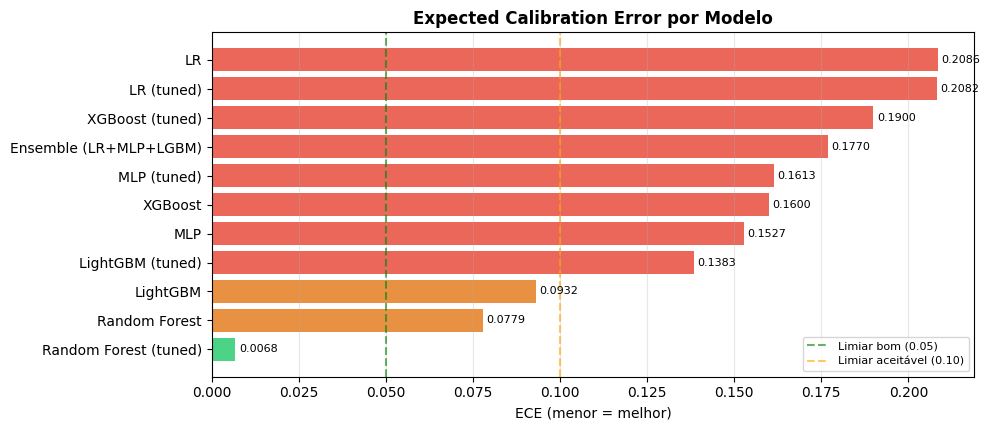

In [4]:
def ece(y_true, y_proba, n_bins=10):
    bins   = np.linspace(0, 1, n_bins + 1)
    total  = len(y_true)
    result = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_proba >= lo) & (y_proba < hi)
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = y_proba[mask].mean()
        result += (mask.sum() / total) * abs(acc - conf)
    return result

rows = []
for base, info in predicoes.items():
    score = ece(info['y_true'], info['y_proba'], n_bins=N_BINS_CAL)
    rows.append({'modelo': info['label'], 'ECE': round(score, 5)})

df_ece = pd.DataFrame(rows).sort_values('ECE').reset_index(drop=True)
display(df_ece)

fig, ax = plt.subplots(figsize=(10, max(4, len(df_ece) * 0.4)))
cores = ['#2ecc71' if v < 0.05 else '#e67e22' if v < 0.10 else '#e74c3c'
         for v in df_ece['ECE']]
bars = ax.barh(df_ece['modelo'], df_ece['ECE'], color=cores, alpha=0.85)
ax.axvline(0.05, color='green',  linestyle='--', alpha=0.6, label='Limiar bom (0.05)')
ax.axvline(0.10, color='orange', linestyle='--', alpha=0.6, label='Limiar aceitável (0.10)')
for bar, val in zip(bars, df_ece['ECE']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('ECE (menor = melhor)')
ax.set_title('Expected Calibration Error por Modelo', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'calibracao_ece.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Calibração por categoria de risco
Verifica se a frequência real de óbito dentro de cada categoria de risco do sistema de scoring
corresponde ao intervalo de probabilidade definido.

In [5]:
rows_cat = []
for base, info in predicoes.items():
    df_p = pd.DataFrame({'y_true': info['y_true'], 'y_proba': info['y_proba']})
    df_p['categoria'] = pd.cut(
        df_p['y_proba'], bins=BINS, labels=CATS, right=False
    )
    for cat in CATS:
        sub = df_p[df_p['categoria'] == cat]
        if len(sub) == 0:
            continue
        rows_cat.append({
            'modelo':          info['label'],
            'categoria':       cat,
            'n_pacientes':     len(sub),
            'n_obitos':        int(sub['y_true'].sum()),
            'freq_real':       round(sub['y_true'].mean(), 4),
            'prob_media':      round(sub['y_proba'].mean(), 4),
        })

df_cat = pd.DataFrame(rows_cat)

print(f'{'Modelo':<30} {'Categoria':<14} {'N':>7} {'Óbitos':>7} {'Freq. Real':>11} {'Prob. Média':>12}')
print('-' * 88)
for modelo in [info['label'] for info in predicoes.values()]:
    sub = df_cat[df_cat['modelo'] == modelo]
    for _, r in sub.iterrows():
        print(f'{r["modelo"]:<30} {r["categoria"]:<14} {r["n_pacientes"]:>7,} '
              f'{r["n_obitos"]:>7,} {r["freq_real"]:>11.4f} {r["prob_media"]:>12.4f}')
    print()

Modelo                         Categoria            N  Óbitos  Freq. Real  Prob. Média
----------------------------------------------------------------------------------------
Ensemble (LR+MLP+LGBM)         BAIXO RISCO     72,547     158      0.0022       0.0507
Ensemble (LR+MLP+LGBM)         MODERADO        49,726     478      0.0096       0.1809
Ensemble (LR+MLP+LGBM)         ALTO RISCO      25,910     751      0.0290       0.4254
Ensemble (LR+MLP+LGBM)         CRÍTICO         12,351   3,908      0.3164       0.8103

LightGBM                       BAIXO RISCO    110,951     662      0.0060       0.0263
LightGBM                       MODERADO        28,725     632      0.0220       0.1787
LightGBM                       ALTO RISCO      12,632     568      0.0450       0.4226
LightGBM                       CRÍTICO          8,226   3,433      0.4173       0.8350

LightGBM (tuned)               BAIXO RISCO     93,026     377      0.0041       0.0329
LightGBM (tuned)               MODERADO

## 5. Reliability diagram — comparação dos melhores modelos

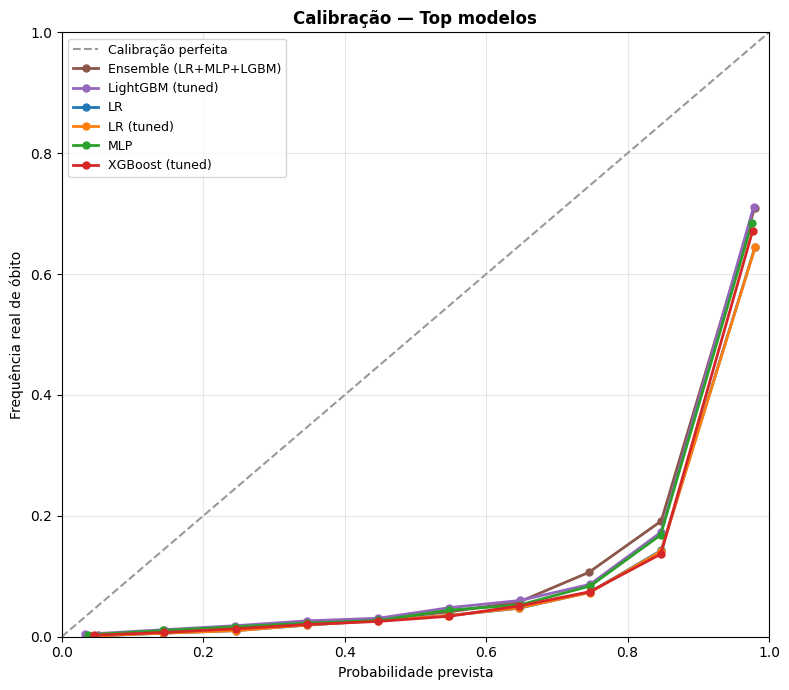

In [6]:
# Top modelos por AUPRC para comparação direta
top_labels = ['LR', 'LR (tuned)', 'MLP', 'XGBoost (tuned)', 'LightGBM (tuned)', 'Ensemble (LR+MLP+LGBM)']
cmap   = plt.get_cmap('tab10')
colors = {label: cmap(i) for i, label in enumerate(top_labels)}

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Calibração perfeita', zorder=0)

for base, info in predicoes.items():
    if info['label'] not in top_labels:
        continue
    prob_true, prob_pred = calibration_curve(
        info['y_true'], info['y_proba'], n_bins=N_BINS_CAL, strategy='uniform'
    )
    ax.plot(prob_pred, prob_true, 'o-', lw=2, markersize=5,
            color=colors[info['label']], label=info['label'])

ax.set_xlabel('Probabilidade prevista')
ax.set_ylabel('Frequência real de óbito')
ax.set_title('Calibração — Top modelos', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'calibracao_top_modelos.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Calibração pós-treinamento — Platt Scaling e Isotonic Regression
Aplica calibração sobre os scores já gerados, sem retreinar os modelos.
Usa cross-calibração em 5 folds no conjunto de teste para evitar vazamento de dados:
em cada fold, o calibrador é treinado nos outros 4 folds e aplicado no fold restante.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix

N_SPLITS = 5

def cross_calibrar(y_true, y_proba, metodo='sigmoid', n_splits=N_SPLITS, seed=42):
    """Calibra scores via cross-validação para evitar vazamento de dados."""
    kf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y_cal  = np.zeros_like(y_proba, dtype=float)

    for train_idx, test_idx in kf.split(y_proba.reshape(-1, 1), y_true):
        y_tr, p_tr = y_true[train_idx], y_proba[train_idx]
        p_te       = y_proba[test_idx]

        if metodo == 'sigmoid':
            cal = LogisticRegression()
            cal.fit(p_tr.reshape(-1, 1), y_tr)
            y_cal[test_idx] = cal.predict_proba(p_te.reshape(-1, 1))[:, 1]
        else:  # isotonic
            cal = IsotonicRegression(out_of_bounds='clip')
            cal.fit(p_tr, y_tr)
            y_cal[test_idx] = cal.predict(p_te)

    return y_cal

def metricas_basicas(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'sensibilidade': round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'auprc':         round(average_precision_score(y_true, y_proba), 4),
        'roc_auc':       round(roc_auc_score(y_true, y_proba), 4),
        'ece':           round(ece(y_true, y_proba), 5),
    }

# Aplica calibração nos modelos principais
top_bases = [b for b, v in predicoes.items()
             if v['label'] in ['LR', 'LR (tuned)', 'MLP', 'XGBoost (tuned)',
                               'LightGBM (tuned)', 'Ensemble (LR+MLP+LGBM)']]

calibrados = {}
for base in top_bases:
    info  = predicoes[base]
    label = info['label']
    y_t   = info['y_true']
    y_p   = info['y_proba']
    print(f'Calibrando {label}...', end=' ', flush=True)
    calibrados[base] = {
        'label':    label,
        'y_true':   y_t,
        'original': y_p,
        'sigmoid':  cross_calibrar(y_t, y_p, metodo='sigmoid'),
        'isotonic': cross_calibrar(y_t, y_p, metodo='isotonic'),
    }
    print('OK')

print('\nConcluído.')

Calibrando Ensemble (LR+MLP+LGBM)... OK
Calibrando LightGBM (tuned)... OK
Calibrando LR... OK
Calibrando LR (tuned)... OK
Calibrando MLP... OK
Calibrando XGBoost (tuned)... OK

Concluído.


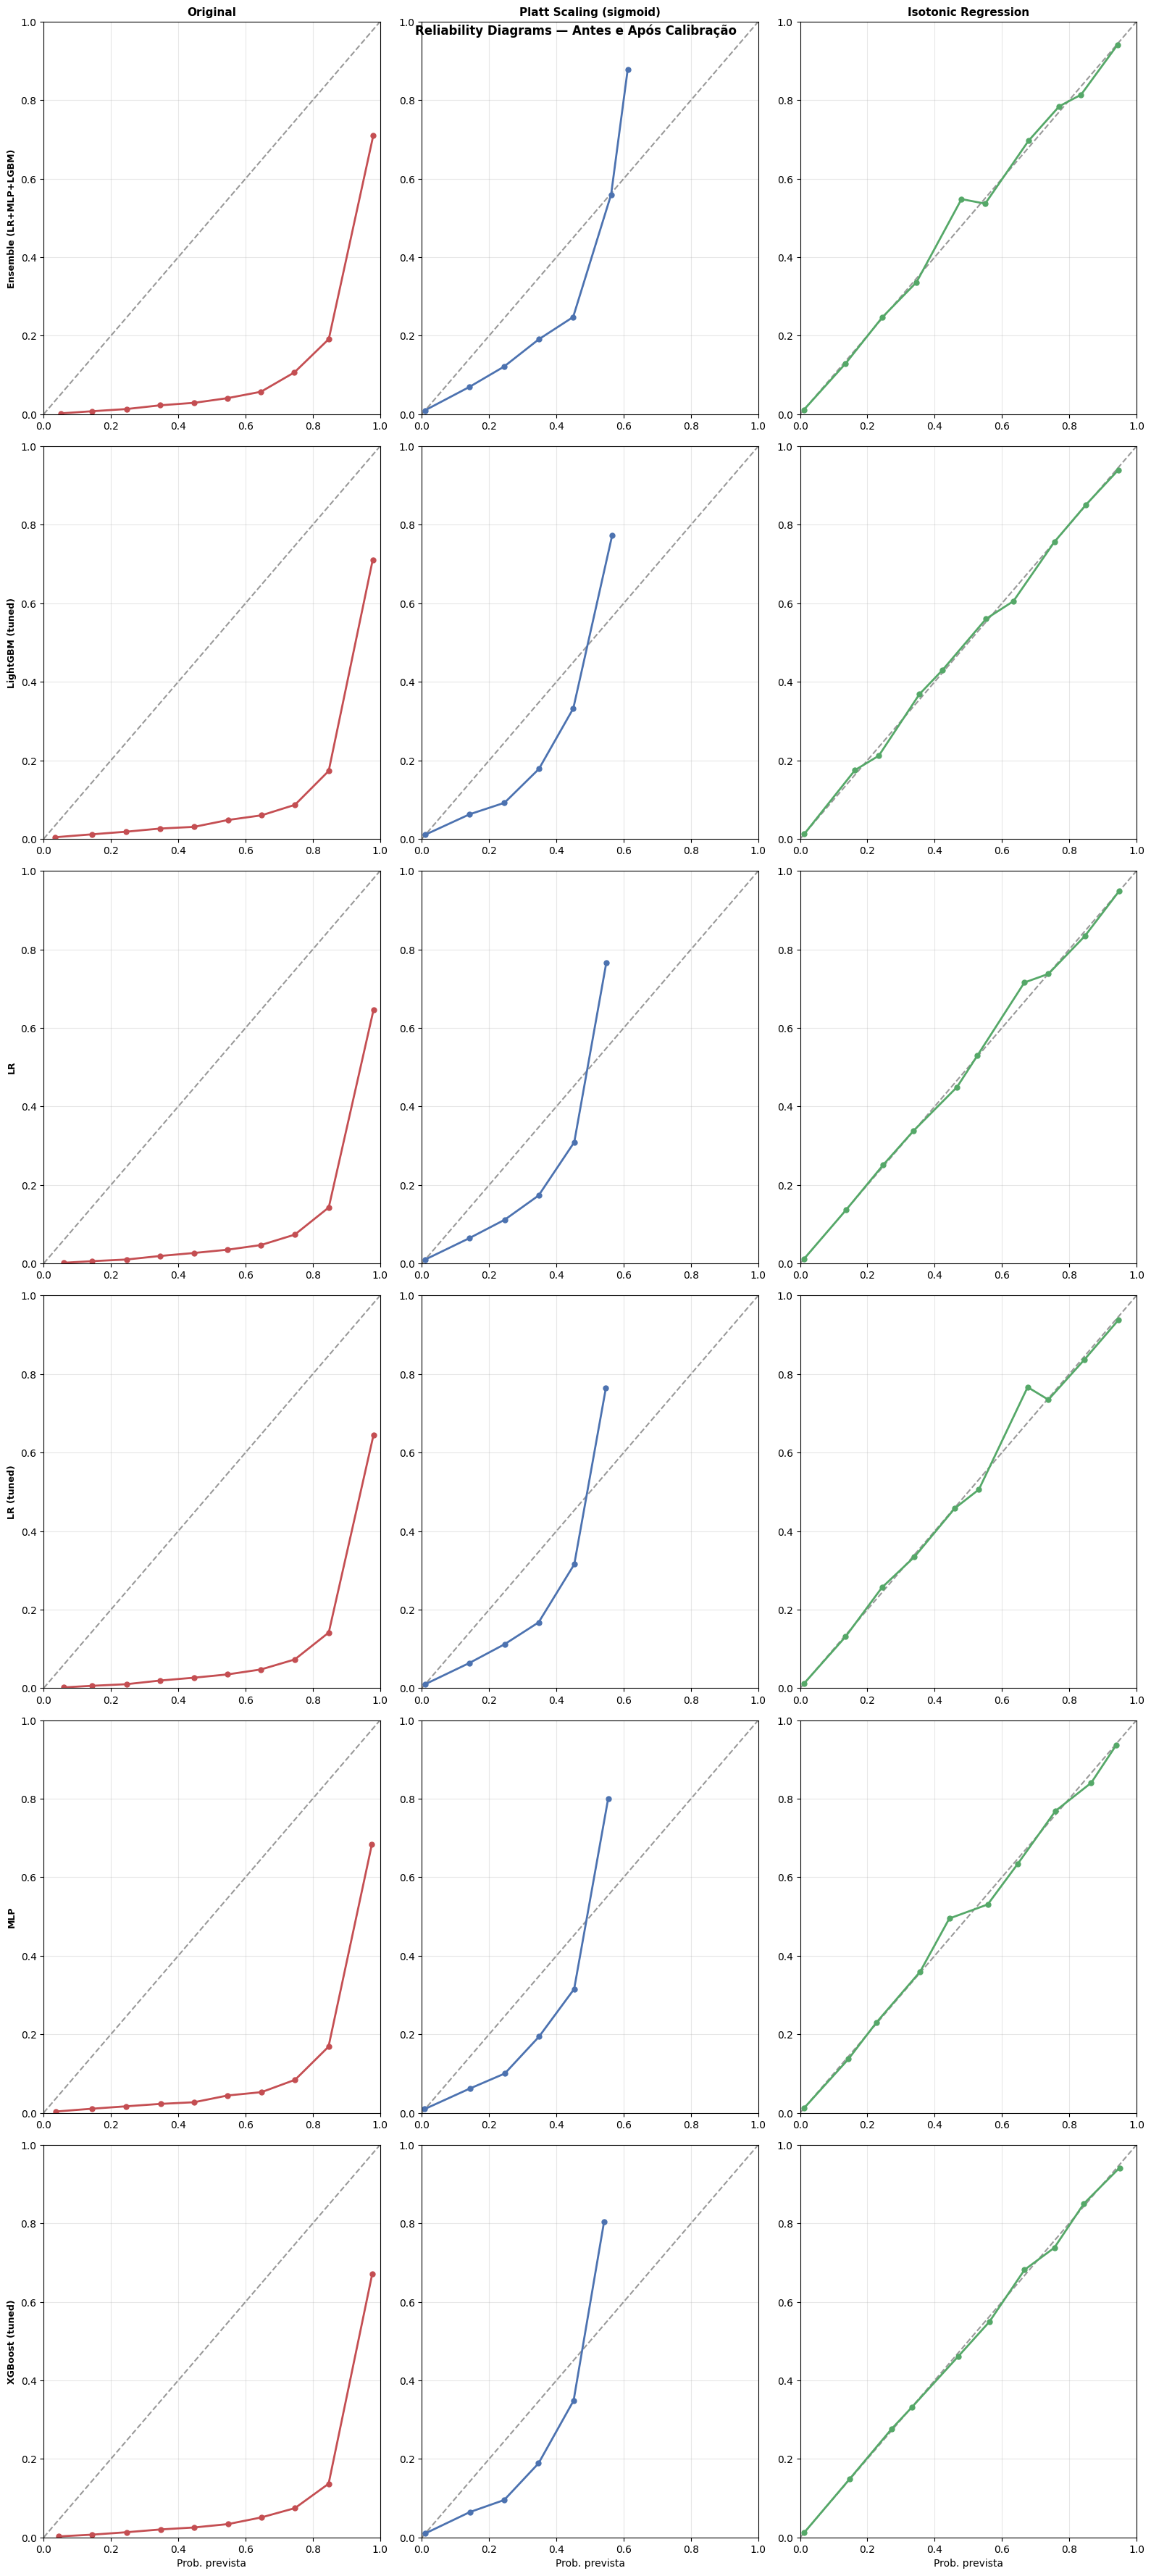

In [8]:
# Reliability diagrams: original vs sigmoid vs isotonic por modelo
n_mod = len(calibrados)
fig, axes = plt.subplots(n_mod, 3, figsize=(16, n_mod * 6))

col_titles = ['Original', 'Platt Scaling (sigmoid)', 'Isotonic Regression']
cores      = ['#C44E52', '#4C72B0', '#55A868']

for row, (base, info) in enumerate(calibrados.items()):
    y_t = info['y_true']
    for col, (versao, cor, titulo) in enumerate(zip(
        ['original', 'sigmoid', 'isotonic'], cores, col_titles
    )):
        ax = axes[row, col]
        pt, pp = calibration_curve(y_t, info[versao], n_bins=N_BINS_CAL, strategy='uniform')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
        ax.plot(pp, pt, 'o-', color=cor, lw=2, markersize=5)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(titulo, fontweight='bold', fontsize=11)
        if col == 0:
            ax.set_ylabel(info['label'], fontsize=9, fontweight='bold')
        if row == n_mod - 1:
            ax.set_xlabel('Prob. prevista')

plt.suptitle('Reliability Diagrams — Antes e Após Calibração', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'calibracao_pos_treino.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Tabela comparativa: ECE e métricas de discriminação antes/após calibração
rows_comp = []
for base, info in calibrados.items():
    y_t = info['y_true']
    for versao in ['original', 'sigmoid', 'isotonic']:
        m = metricas_basicas(y_t, info[versao])
        rows_comp.append({'modelo': info['label'], 'versao': versao, **m})

df_comp_cal = pd.DataFrame(rows_comp)

print(f"{'Modelo':<28} {'Versão':<12} {'Sensib.':>9} {'AUPRC':>8} {'ROC-AUC':>9} {'ECE':>8}")
print('-' * 80)
for modelo in [v['label'] for v in calibrados.values()]:
    sub = df_comp_cal[df_comp_cal['modelo'] == modelo]
    for _, r in sub.iterrows():
        print(f"{r['modelo']:<28} {r['versao']:<12} {r['sensibilidade']:>9.4f} "
              f"{r['auprc']:>8.4f} {r['roc_auc']:>9.4f} {r['ece']:>8.5f}")
    print()

Modelo                       Versão         Sensib.    AUPRC   ROC-AUC      ECE
--------------------------------------------------------------------------------
Ensemble (LR+MLP+LGBM)       original        0.7843   0.6472    0.9261  0.17696
Ensemble (LR+MLP+LGBM)       sigmoid         0.5658   0.6440    0.9260  0.00995
Ensemble (LR+MLP+LGBM)       isotonic        0.5377   0.6418    0.9251  0.00049

LightGBM (tuned)             original        0.7549   0.6294    0.9136  0.13833
LightGBM (tuned)             sigmoid         0.5335   0.6293    0.9134  0.01158
LightGBM (tuned)             isotonic        0.5126   0.6241    0.9121  0.00031

LR                           original        0.8004   0.6250    0.9242  0.20857
LR                           sigmoid         0.5409   0.6124    0.9240  0.01140
LR                           isotonic        0.5033   0.6223    0.9230  0.00031

LR (tuned)                   original        0.8008   0.6250    0.9242  0.20825
LR (tuned)                   sigmoid

## 7. Threshold ótimo pós-calibração (isotonic)
Após calibração isotônica os scores passam a refletir a prevalência real (~3.3%).
O threshold 0.5 classifica quase ninguém como óbito — precisa ser recalibrado.
Varre thresholds de 0.01 a 0.50 e identifica o ponto de operação ideal para cada modelo.

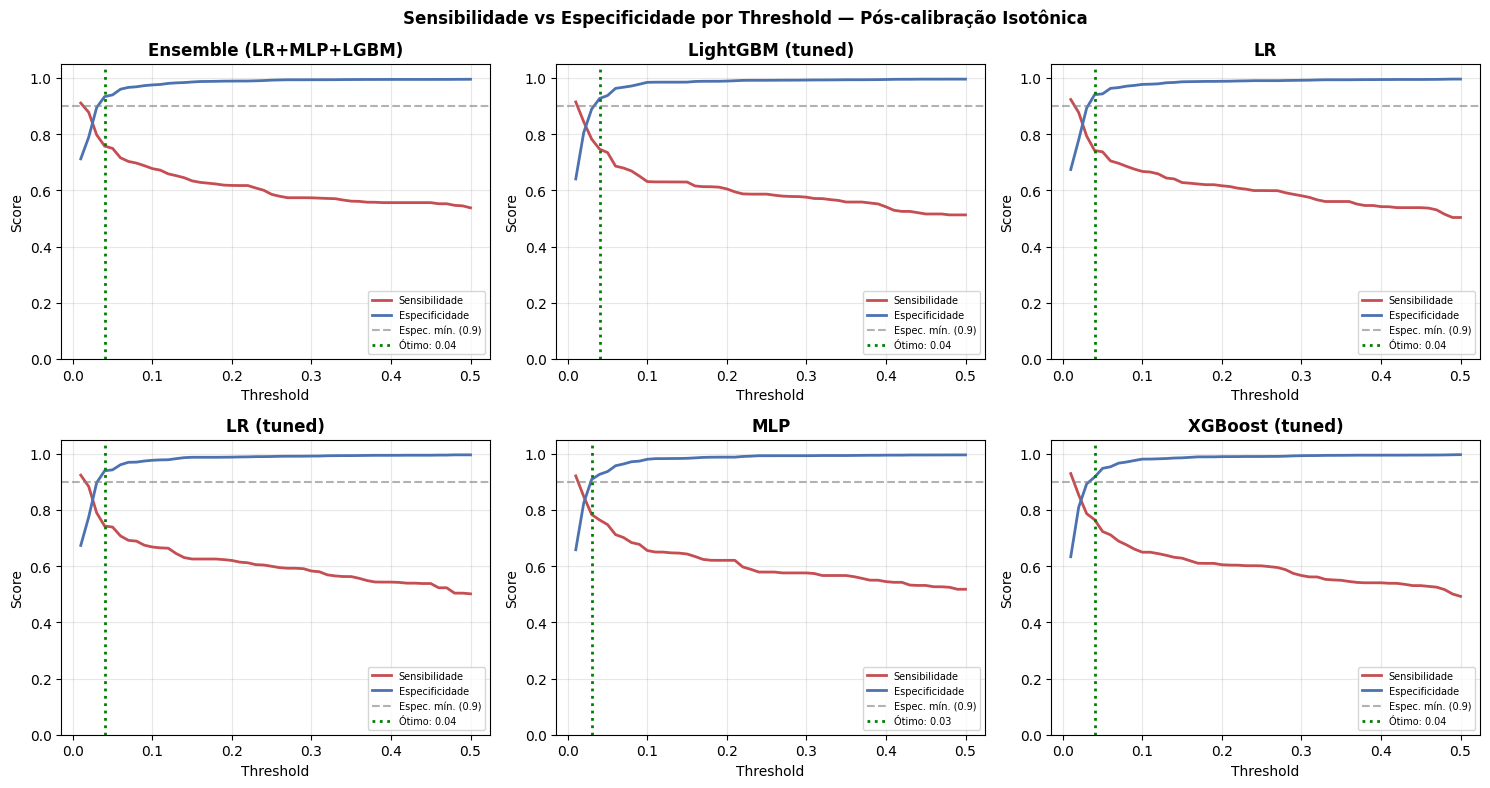


=== Threshold ótimo por modelo (especificidade mínima = 0.9) ===



,modelo,threshold_otimo,sensibilidade,especificidade,auprc,roc_auc
0,MLP,0.03,0.7834,0.9084,0.6335,0.9208
1,XGBoost (tuned),0.04,0.7649,0.9166,0.6246,0.9179
2,Ensemble (LR+MLP+LGBM),0.04,0.7573,0.9335,0.6418,0.9251
3,LightGBM (tuned),0.04,0.7464,0.9267,0.6241,0.9121
4,LR (tuned),0.04,0.7424,0.9390,0.6219,0.9231
5,LR,0.04,0.7415,0.9403,0.6223,0.9230


In [12]:
SPEC_MINIMA = 0.90  # especificidade mínima aceitável
thresholds  = np.arange(0.01, 0.51, 0.01)

rows_thr = []
for base, info in calibrados.items():
    y_t  = info['y_true']
    y_p  = info['isotonic']
    for thr in thresholds:
        y_pred = (y_p >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        rows_thr.append({
            'modelo':        info['label'],
            'threshold':     round(thr, 2),
            'sensibilidade': round(sens, 4),
            'especificidade': round(spec, 4),
        })

df_thr = pd.DataFrame(rows_thr)

# --- Gráfico: curvas sensibilidade e especificidade por threshold ---
modelos_cal = [v['label'] for v in calibrados.values()]
ncols = 3
nrows = (len(modelos_cal) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, modelo in enumerate(modelos_cal):
    ax  = axes[i]
    sub = df_thr[df_thr['modelo'] == modelo]
    ax.plot(sub['threshold'], sub['sensibilidade'],  color='#C44E52', lw=2, label='Sensibilidade')
    ax.plot(sub['threshold'], sub['especificidade'], color='#4C72B0', lw=2, label='Especificidade')
    ax.axhline(SPEC_MINIMA, color='gray', linestyle='--', alpha=0.6, label=f'Espec. mín. ({SPEC_MINIMA})')

    # threshold ótimo: máxima sensibilidade com especificidade >= SPEC_MINIMA
    validos = sub[sub['especificidade'] >= SPEC_MINIMA]
    if len(validos) > 0:
        melhor = validos.loc[validos['sensibilidade'].idxmax()]
        ax.axvline(melhor['threshold'], color='green', linestyle=':', lw=2,
                   label=f"Ótimo: {melhor['threshold']:.2f}")

    ax.set_title(modelo, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sensibilidade vs Especificidade por Threshold — Pós-calibração Isotônica',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'threshold_otimo_calibrado.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Tabela: threshold ótimo e métricas resultantes ---
rows_otimo = []
for base, info in calibrados.items():
    y_t  = info['y_true']
    y_p  = info['isotonic']
    sub  = df_thr[df_thr['modelo'] == info['label']]
    validos = sub[sub['especificidade'] >= SPEC_MINIMA]
    if len(validos) == 0:
        continue
    melhor = validos.loc[validos['sensibilidade'].idxmax()]
    thr    = melhor['threshold']
    y_pred = (y_p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()
    rows_otimo.append({
        'modelo':          info['label'],
        'threshold_otimo': thr,
        'sensibilidade':   round(tp / (tp + fn), 4),
        'especificidade':  round(tn / (tn + fp), 4),
        'auprc':           round(average_precision_score(y_t, y_p), 4),
        'roc_auc':         round(roc_auc_score(y_t, y_p), 4),
    })

df_otimo = pd.DataFrame(rows_otimo).sort_values('sensibilidade', ascending=False)
print(f'\n=== Threshold ótimo por modelo (especificidade mínima = {SPEC_MINIMA}) ===\n')
display(df_otimo.reset_index(drop=True))

## 8. Salvamento

In [13]:
ece_path = os.path.join(OUTPUT_MET, 'calibracao_ece.csv')
df_ece.to_csv(ece_path, index=False)
print(f'ECE salvo: {ece_path}')

cat_path = os.path.join(OUTPUT_MET, 'calibracao_por_categoria.csv')
df_cat.to_csv(cat_path, index=False)
print(f'Calibração por categoria salva: {cat_path}')

comp_path = os.path.join(OUTPUT_MET, 'calibracao_pos_treino.csv')
df_comp_cal.to_csv(comp_path, index=False)
print(f'Comparação pós-calibração salva: {comp_path}')

ECE salvo: ../../output/metricas/calibracao_ece.csv
Calibração por categoria salva: ../../output/metricas/calibracao_por_categoria.csv
Comparação pós-calibração salva: ../../output/metricas/calibracao_pos_treino.csv
